# Projeto Fundamentos de Aprendizagem Automática Grupo 22

#### jiyi Li 62244
#### oujie Wu 62228
#### josé lourenço 62817
  

## Probelma:Estimar a nota final com base student_hour,gaming_hours,sleep_hours,exercise_minutes......

### Variáveis-Alvo (Targets):

### Cenário de Regressão (y): Estimar Exam Score (nota de exame). Por exemplo, um valor entre 0 e 100.

###    Cenário de Classificação (y): Transformar a variável Exam Score em categorias discretas e interpretáveis. Com base na distribuição dos dados ou em critérios pedagógicos, podemos definir:
        

### Classificacao multiclass:
            Insuficiente: exame Score 0 a 49
            Suficiente:   exame Score 50 a 69
            Bom:          exame Score 70 a 89
            Excelente:    exame Score 90 a 100
    
Stakeholders:
    Os próprios estudantes
    A instituição de ensino / escola
    onselheiros / Tutores / Serviços de Apoio ao Estudante

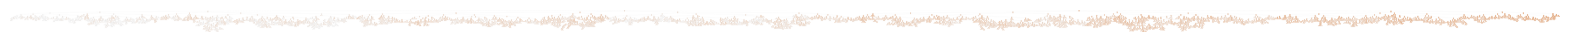

In [8]:
import pandas as pd
import numpy as np
from sklearn import tree
from sklearn.model_selection import train_test_split
import io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pydot


def display_tree(the_tree, feature_names, class_names, fname=None, figsize=(10,10)):
    dot_data = tree.export_graphviz(
        the_tree,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        special_characters=True
    )

    graph = pydot.graph_from_dot_data(dot_data)[0]
    png = graph.create_png()

    img = mpimg.imread(io.BytesIO(png))

    plt.figure(figsize=figsize)
    plt.axis("off")
    plt.imshow(img)

    if fname:
        graph.write_png(f"{fname}.png")





# ler ficherio de stufent_records
df_student_records = pd.read_csv('student_records_full.csv')
# print(df_student_records)


df_colunas = df_student_records.columns
# print(df_colunas)
df_y = df_student_records['exam_score']
# print(df_y)
df_student_records.drop(columns=["student_id", "exam_score"], inplace=True)
df_student_records_copy = df_student_records.copy()
# print(df_student_records)
df_categorico = df_student_records[["gender","academic_level","internet_quality"]]
# print(df_categorico)
df_numerico = df_student_records.drop(columns=["gender", "academic_level", "internet_quality"], inplace=True)
# print(df_student_records)


df_X = df_student_records_copy
df_X = pd.get_dummies(df_X)

X = df_X.values
y = df_y


X_train, X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

cdt_student = tree.DecisionTreeRegressor()
cdt_student = cdt_student.fit(X_train, y_train)
cdt_student

display_tree(cdt_student, feature_names=df_X.columns, class_names=None, fname="student_decision_tree", figsize=(20,20))



